In [52]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn import svm
from sklearn.linear_model import LogisticRegression

In [54]:
df=pd.read_csv("C:\\Users\\dhruv\\Downloads\\archive (3)\\Twitter_Data.csv")

In [56]:
df.shape

(162980, 2)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [60]:
df['category'].value_counts()

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

In [62]:
labels = pd.get_dummies(df.category)
labels.columns = ["negative", "neutral", "positive"]
labels.head()

,negative,neutral,positive
0,True,False,False
1,False,True,False
2,False,False,True
3,False,False,True
4,False,False,True


<Axes: xlabel='category', ylabel='count'>

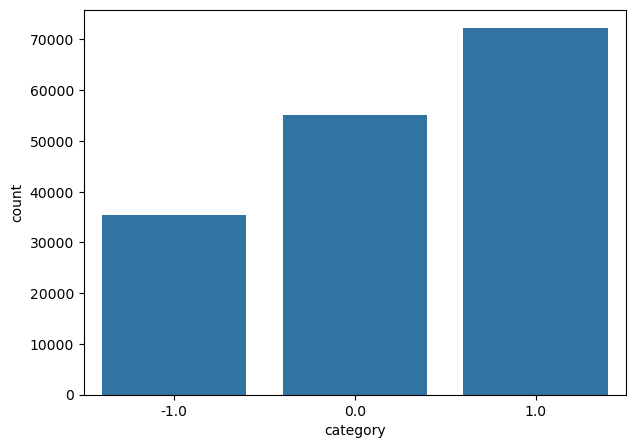

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(7,5))
sns.countplot(x="category",data=df)

Text(0.5, 1.0, 'Distribution of sentiments')

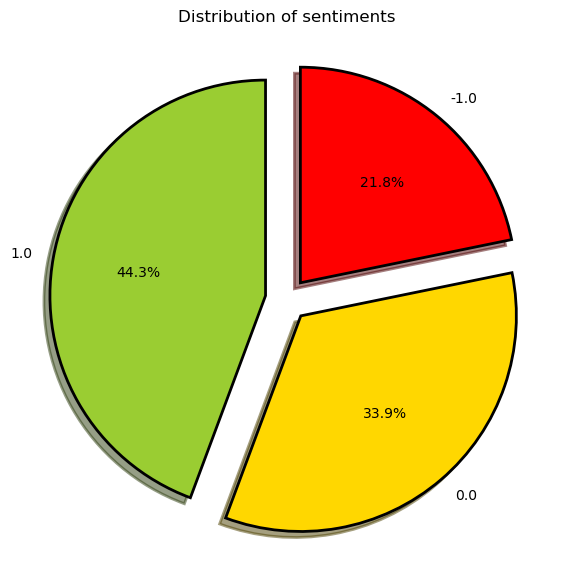

In [66]:
fig = plt.figure(figsize=(7,7))
colors = ("yellowgreen", "gold", "red")
wp = {'linewidth':2, 'edgecolor':"black"}
tags = df['category'].value_counts()
explode = (0.1,0.1,0.1)
tags.plot(kind='pie', autopct='%1.1f%%', shadow=True, colors = colors,
         startangle=90, wedgeprops = wp, explode = explode, label='')
plt.title('Distribution of sentiments')

In [68]:
!pip install wordcloud

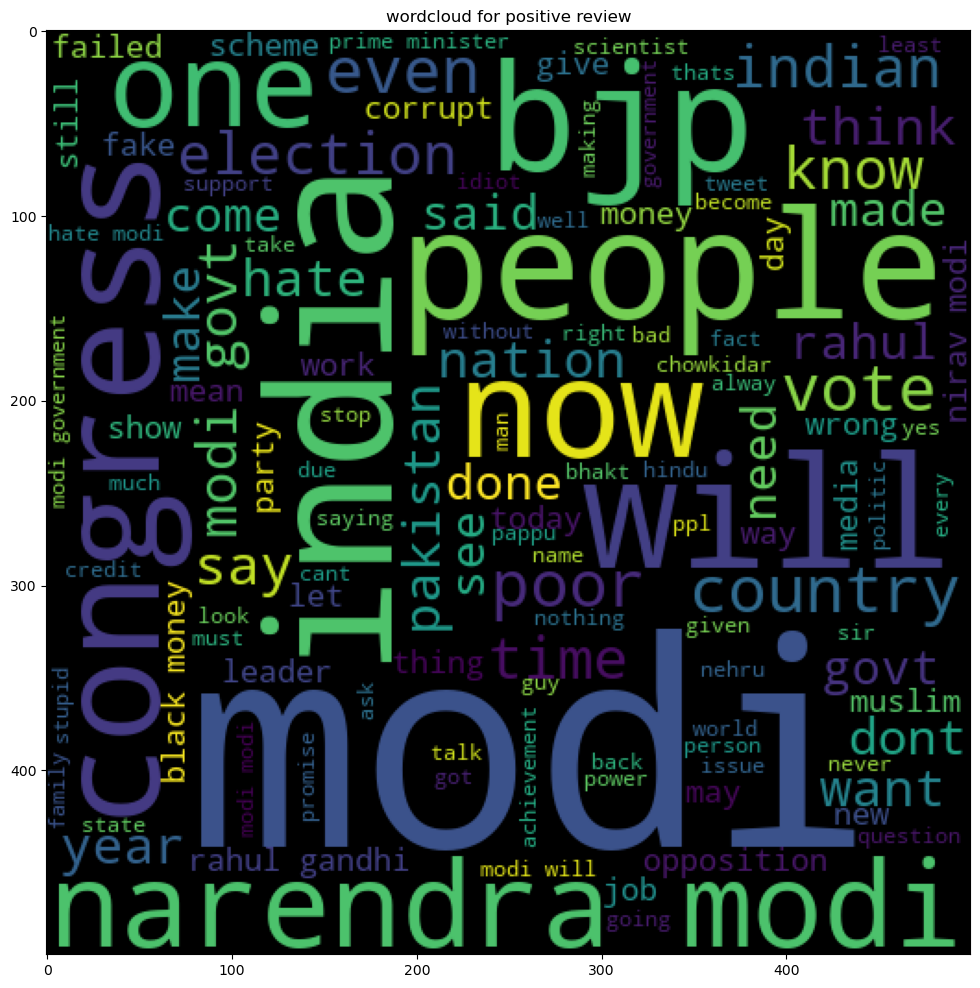

In [84]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'black')
positive_wc = wc.generate(df[df['category'] == 1.0]['clean_text'].str.cat(sep = " "))
neutral_wc = wc.generate(df[df['category'] == 0.0]['clean_text'].str.cat(sep = " "))
negative_wc = wc.generate(df[df['category'] == -1.0]['clean_text'].str.cat(sep = " "))
plt.figure(figsize = (12, 12))
plt.title('wordcloud for positive review')
plt.imshow(positive_wc)

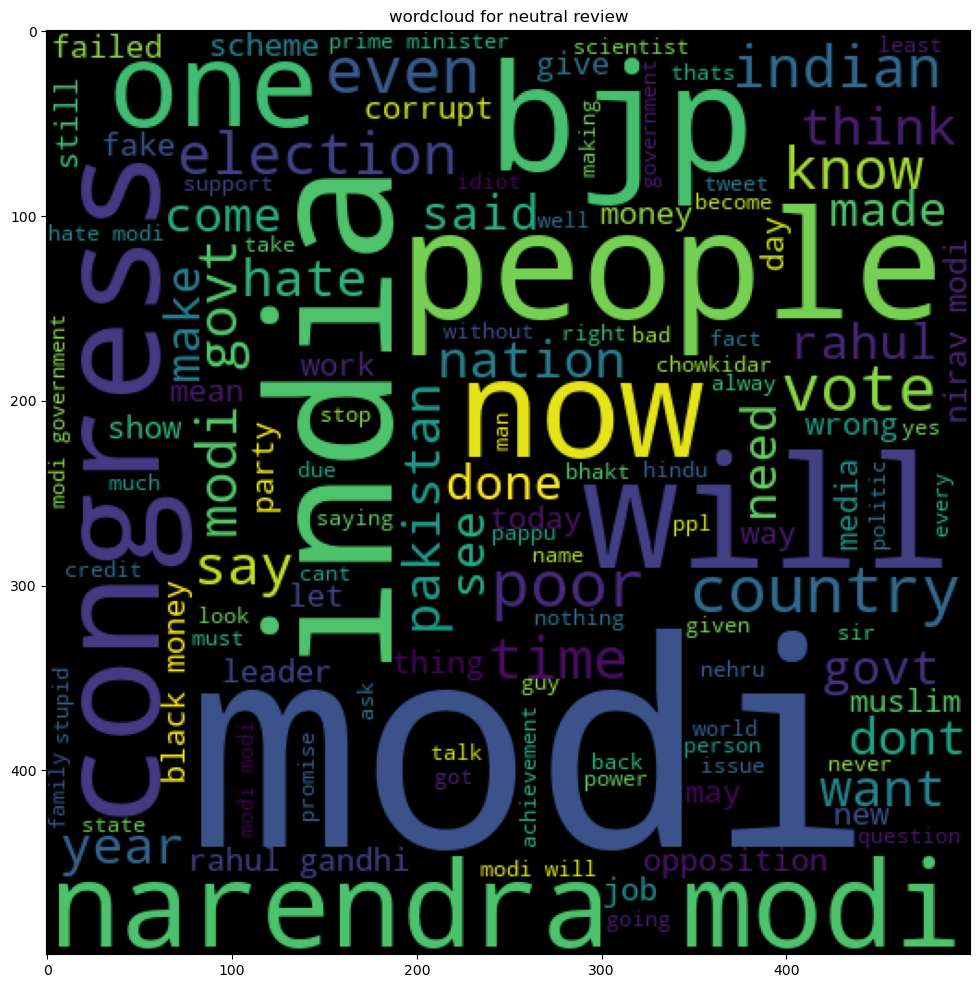

In [86]:
plt.figure(figsize = (12, 12))
plt.title('wordcloud for neutral review')
plt.imshow(neutral_wc)

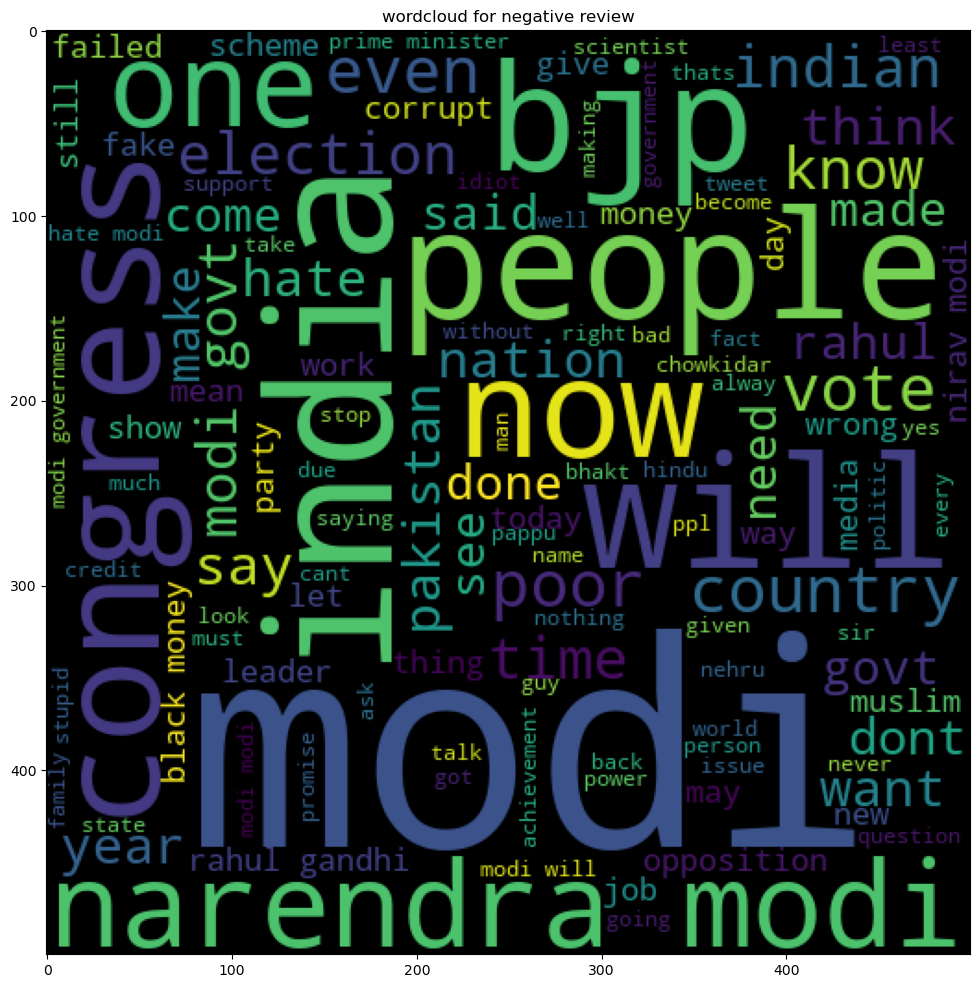

In [88]:
plt.figure(figsize = (12, 12))
plt.title('wordcloud for negative review')
plt.imshow(negative_wc)

In [96]:
def preprocess_tweet(tweet):
    # Ensure tweet is a string
    tweet = str(tweet) if not pd.isna(tweet) else ""
    # Remove URLs
    tweet = re.sub(r'http\S+', '', tweet)
    # Remove mentions
    tweet = re.sub(r'@\w+', '', tweet)
    # Remove hashtags (optional, keep if needed for sentiment analysis, otherwise remove)
    tweet = re.sub(r'#\w+', '', tweet)
    # Remove digits
    tweet = re.sub(r'\d+', '', tweet)
    # Remove non-word characters and extra spaces
    tweet = re.sub(r'\W+', ' ', tweet)
    tweet = re.sub(r'\s+', ' ', tweet).strip()
    return tweet

# Apply preprocessing
df['cleaned_text'] = df['clean_text'].apply(preprocess_tweet)
df['cleaned_text'].fillna("missing", inplace=True)

# Handling missing values in the 'category' column
df.dropna(subset=['category'], inplace=True)
df['category'] = df['category'].astype(int)

print(df[['cleaned_text', 'category']].head())

                                        cleaned_text  category
0  when modi promised minimum government maximum ...        -1
1  talk all the nonsense and continue all the dra...         0
2  what did just say vote for modi welcome bjp to...         1
3  asking his supporters prefix chowkidar their n...         1
4  answer who among these the most powerful world...         1


C:\Users\dhruv\AppData\Local\Temp\ipykernel_18232\3083981984.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cleaned_text'].fillna("missing", inplace=True)


In [98]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['category'], test_size=0.2, random_state=42)

In [100]:
# Count Vectorizer
cvectorizer = CountVectorizer()
X_train_vectorized = cvectorizer.fit_transform(X_train)
X_test_vectorized = cvectorizer.transform(X_test)

In [102]:
# Multinomial Naive Bayes Classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vectorized, y_train)
y_pred = nb_classifier.predict(X_test_vectorized)

In [104]:
# Results
print("Classification Report (ML-based):")
print(classification_report(y_test, y_pred))
print("Accuracy Score (ML-based):")
print(accuracy_score(y_test, y_pred))

Classification Report (ML-based):
              precision    recall  f1-score   support

          -1       0.75      0.62      0.68      7230
           0       0.91      0.62      0.74     10961
           1       0.69      0.92      0.79     14404

    accuracy                           0.75     32595
   macro avg       0.78      0.72      0.74     32595
weighted avg       0.78      0.75      0.75     32595

Accuracy Score (ML-based):
0.7525387329344991


In [106]:
# Count Vectorizer with N-grams
cvectorizer = CountVectorizer(ngram_range=(1, 4))
X_train_vectorized = cvectorizer.fit_transform(X_train)
X_test_vectorized = cvectorizer.transform(X_test)
nb_classifier.fit(X_train_vectorized, y_train)
y_pred = nb_classifier.predict(X_test_vectorized)

print("Classification Report (ML-based with n-grams):")
print(classification_report(y_test, y_pred))
print("Accuracy Score (ML-based with n-grams):")
print(accuracy_score(y_test, y_pred))

Classification Report (ML-based with n-grams):
              precision    recall  f1-score   support

          -1       0.87      0.23      0.36      7230
           0       0.90      0.29      0.44     10961
           1       0.52      0.98      0.68     14404

    accuracy                           0.58     32595
   macro avg       0.76      0.50      0.49     32595
weighted avg       0.73      0.58      0.53     32595

Accuracy Score (ML-based with n-grams):
0.5801810093572634


In [108]:
# TF-IDF Vectorizer with Trigrams
vectorizertf = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_train_vectorized = vectorizertf.fit_transform(X_train)
X_test_vectorized = vectorizertf.transform(X_test)
nb_classifier = MultinomialNB(alpha=0.1)
nb_classifier.fit(X_train_vectorized, y_train)
y_pred = nb_classifier.predict(X_test_vectorized)

print("Classification Report (ML-based with TF-IDF and trigrams):")
print(classification_report(y_test, y_pred))
print("Accuracy Score (ML-based with TF-IDF and trigrams):")
print(accuracy_score(y_test, y_pred))

Classification Report (ML-based with TF-IDF and trigrams):
              precision    recall  f1-score   support

          -1       0.85      0.47      0.61      7230
           0       0.85      0.72      0.78     10961
           1       0.69      0.92      0.79     14404

    accuracy                           0.75     32595
   macro avg       0.80      0.70      0.72     32595
weighted avg       0.78      0.75      0.74     32595

Accuracy Score (ML-based with TF-IDF and trigrams):
0.7531830035281485


In [110]:
# Vectorizing the text
cvectorizer = CountVectorizer()
X = cvectorizer.fit_transform(df['cleaned_text'])
y = df['category']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training a Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Predicting and evaluating the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.73      0.63      0.68      7230
           0       0.91      0.63      0.74     10961
           1       0.70      0.90      0.79     14404

    accuracy                           0.75     32595
   macro avg       0.78      0.72      0.74     32595
weighted avg       0.77      0.75      0.75     32595

Accuracy: 0.7514649486117503


In [112]:
LR=LogisticRegression()
LR.fit(X_train_vectorized, y_train)

C:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [114]:
LR_pred = LR.predict(X_test_vectorized)

In [116]:
print("Classification Report (Logistic regression):")
print(classification_report(y_test, LR_pred))
print("Accuracy Score (Logistic regression):")
print(accuracy_score(y_test, LR_pred))

Classification Report (Logistic regression):
              precision    recall  f1-score   support

          -1       0.90      0.79      0.84      7230
           0       0.89      0.97      0.93     10961
           1       0.93      0.92      0.92     14404

    accuracy                           0.91     32595
   macro avg       0.91      0.89      0.90     32595
weighted avg       0.91      0.91      0.91     32595

Accuracy Score (Logistic regression):
0.9071023163061819


In [118]:
# New Cell for Tweet Sentiment Analysis
def analyze_tweet_sentiment(tweet, model, vectorizertf):

    tweet_vectorized = vectorizertf.transform([tweet])
    sentiment = model.predict(tweet_vectorized)[0]
    
    if sentiment == 1:
        return "The sentiment for the previous tweet is positive."
    elif sentiment == 0:
        return "The sentiment for the previous tweet is neutral."
    else:
        return "The sentiment for the previous tweet is negative."

# Example Usage
new_tweet = input("Enter a tweet: The sentiment for the previous tweet is positive. ")
print(analyze_tweet_sentiment(new_tweet, LR, vectorizertf))

Enter a tweet:  h


The sentiment for the previous tweet is neutral.


In [ ]:
new_tweet = input("Enter a tweet: ")
print(analyze_tweet_sentiment(new_tweet, LR, vectorizertf))